<a href="https://colab.research.google.com/github/ashitasingh1230-commits/IT_support_ticket_analysis/blob/main/01_sla_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **IT Support Ticket Analysis**

### 1. Load & Explore Data

In [1]:
import pandas as pd
df=pd.read_csv('itsm_ticket_corpus_flat.csv')
df.head()


,record_id,record_type,ticket,status,correspondence,diagnostics,root_cause,resolution
0,INC-ALP-0001,incident,"{""submitted_at"": ""2025-11-18T08:00:00Z"", ""subm...",closed,"[{""turn_id"": 1, ""role"": ""agent"", ""event_type"":...","{""coverage"": ""standard"", ""summary"": ""Diagnosti...",Cached credentials on the user's iPhone contin...,"{""steps"": [""Reviewed Active Directory lockout ..."
1,INC-ALP-0002,incident,"{""submitted_at"": ""2025-11-18T13:48:00Z"", ""subm...",closed,"[{""turn_id"": 1, ""role"": ""agent"", ""event_type"":...","{""coverage"": ""standard"", ""summary"": ""Diagnosti...",Stale cached credentials on the user's iOS mob...,"{""steps"": [""Reviewed account lockout activity ..."
2,INC-ALP-0003,incident,"{""submitted_at"": ""2025-11-18T19:36:00Z"", ""subm...",closed,"[{""turn_id"": 1, ""role"": ""agent"", ""event_type"":...","{""coverage"": ""standard"", ""summary"": ""Diagnosti...",Active Directory lockout policy was triggered ...,"{""steps"": [""Reviewed the account status for md..."
3,INC-ALP-0004,incident,"{""submitted_at"": ""2025-11-19T01:24:00Z"", ""subm...",closed,"[{""turn_id"": 1, ""role"": ""agent"", ""event_type"":...","{""coverage"": ""standard"", ""summary"": ""Diagnosti...",The Active Directory lockout policy was trigge...,"{""steps"": [""Unlock the user's Active Directory..."
4,INC-ALP-0005,incident,"{""submitted_at"": ""2025-11-19T07:12:00Z"", ""subm...",closed,"[{""turn_id"": 1, ""role"": ""agent"", ""event_type"":...","{""coverage"": ""standard"", ""summary"": ""Diagnosti...",Active Directory lockout policy was triggered ...,"{""steps"": [""Reviewed Active Directory lockout ..."


In [2]:
df.columns

Index(['record_id', 'record_type', 'ticket', 'status', 'correspondence',
       'diagnostics', 'root_cause', 'resolution'],
      dtype='object')

In [3]:
df.shape

(745, 8)

In [4]:
df['record_type'].value_counts()

,count
record_type,
incident,745


In [6]:
df['status'].value_counts()

,count
status,
closed,745


In [7]:
df['root_cause'].value_counts()

,count
root_cause,
"Likely mailbox-side Exchange Online synchronization fault or service condition affecting multiple clients for a single user, not caused by mobile device compliance or a simple stale local Outlook session.",1
"Cached credentials on the user's iPhone continued submitting the old password after the reset, generating repeated failed authentications against Active Directory and triggering the account lockout policy before the new password could be used successfully in SSO.",1
"Stale cached credentials on the user's iOS mobile device continued submitting the old password to Active Directory and SSO-connected services after the self-service password reset, repeatedly triggering the AD lockout policy.",1
"Active Directory lockout policy was triggered by repeated failed sign-in attempts from the user's iOS mobile device, which continued using cached pre-reset credentials after the prior password reset token expired before the device updated its stored authentication data.",1
"The Active Directory lockout policy was triggered by repeated authentication attempts from a mobile device using stale cached credentials. While the password reset request completed in the Password Reset Portal, the locked account state and delayed propagation of the new credential to the SSO path prevented successful sign-in until the lockout source was remediated and the account state was synchronized.",1
...,...
"Repeated AD lockouts were caused by stale cached credentials and saved authentication tokens on the user's company iPhone, which continued sending failed sign-in attempts to SSO/Active Directory after the initial unlock. The earlier remediation restored account access temporarily but did not remove the outdated mobile credentials, so the lockout condition recurred.",1
"Active Directory lockout was repeatedly re-triggered by a mobile device using cached or expired corporate credentials. Although the user completed a password reset, the stale mobile authentication attempts continued to submit the old password and prevented the account from remaining unlocked long enough for normal sign-in.",1
"Active Directory domain lockout policy was triggered by repeated failed authentication attempts from a mobile device with stale cached credentials, preventing SSO access; the user's reset attempt did not complete recovery because the password reset token had already expired.",1


In [10]:
df['root_cause'].iloc[0]

"Cached credentials on the user's iPhone continued submitting the old password after the reset, generating repeated failed authentications against Active Directory and triggering the account lockout policy before the new password could be used successfully in SSO."

In [11]:
df['ticket'].iloc[0]

'{"submitted_at": "2025-11-18T08:00:00Z", "submitted_title": "AD account locked after password reset", "submitted_description": "I completed a corporate password reset through the Password Reset Portal on 2025-11-18 at approximately 07:45 UTC, but sign-in to the SSO Portal at https://sso.corplabs.com continued to fail with a locked-account error and my Active Directory account (username: mcarson) became locked again within minutes. I primarily authenticate from my iPhone (WORKSTATION-IPHONE-MC) at the Charlotte office, with previously saved credentials in the iOS Mail app and Safari browser, which prevented successful access to corporate resources including Outlook and SharePoint after the password change. My employee ID is EMP-20418 and I need access restored urgently for a client presentation this morning.", "priority": "high", "sla_plan": "Business-hours SLA", "environment": {"os": "iOS 15.6", "platform": "mobile", "region": "us-east-1", "user_group": "Corp Users"}, "applications": 

In [12]:
import json

In [13]:
first_ticket=json.loads(df['ticket'].iloc[0])
first_ticket

{'submitted_at': '2025-11-18T08:00:00Z',
 'submitted_title': 'AD account locked after password reset',
 'submitted_description': 'I completed a corporate password reset through the Password Reset Portal on 2025-11-18 at approximately 07:45 UTC, but sign-in to the SSO Portal at https://sso.corplabs.com continued to fail with a locked-account error and my Active Directory account (username: mcarson) became locked again within minutes. I primarily authenticate from my iPhone (WORKSTATION-IPHONE-MC) at the Charlotte office, with previously saved credentials in the iOS Mail app and Safari browser, which prevented successful access to corporate resources including Outlook and SharePoint after the password change. My employee ID is EMP-20418 and I need access restored urgently for a client presentation this morning.',
 'priority': 'high',
 'sla_plan': 'Business-hours SLA',
 'environment': {'os': 'iOS 15.6',
  'platform': 'mobile',
  'region': 'us-east-1',
  'user_group': 'Corp Users'},
 'appl

In [14]:
first_ticket['priority']

'high'

In [15]:
print(first_ticket['submitted_title'])
print(first_ticket['sla_plan'])
print(first_ticket['environment'])

AD account locked after password reset
Business-hours SLA
{'os': 'iOS 15.6', 'platform': 'mobile', 'region': 'us-east-1', 'user_group': 'Corp Users'}


In [16]:
df['ticket_parsed']=df['ticket'].apply(json.loads)

In [17]:
df['ticket_parsed'].iloc[0]

{'submitted_at': '2025-11-18T08:00:00Z',
 'submitted_title': 'AD account locked after password reset',
 'submitted_description': 'I completed a corporate password reset through the Password Reset Portal on 2025-11-18 at approximately 07:45 UTC, but sign-in to the SSO Portal at https://sso.corplabs.com continued to fail with a locked-account error and my Active Directory account (username: mcarson) became locked again within minutes. I primarily authenticate from my iPhone (WORKSTATION-IPHONE-MC) at the Charlotte office, with previously saved credentials in the iOS Mail app and Safari browser, which prevented successful access to corporate resources including Outlook and SharePoint after the password change. My employee ID is EMP-20418 and I need access restored urgently for a client presentation this morning.',
 'priority': 'high',
 'sla_plan': 'Business-hours SLA',
 'environment': {'os': 'iOS 15.6',
  'platform': 'mobile',
  'region': 'us-east-1',
  'user_group': 'Corp Users'},
 'appl

In [18]:
df['priority']=df['ticket_parsed'].apply(lambda x : x['priority'])

In [19]:
df['priority'].value_counts()

,count
priority,
medium,254
high,249
low,242


### **2. Clean SLA Plan Categories**

In [20]:
df['sla_plan']=df['ticket_parsed'].apply(lambda x : x['sla_plan'])
df['sla_plan'].value_counts()

,count
sla_plan,
Standard Business Hours,99
Standard,47
standard,41
Gold,30
Standard SLA,17
...,...
Corporate SLA - Standard 8x5,1
Corporate-Network-SLA,1
Tier 2 Network - 4 hour response,1


In [21]:
df['sla_plan_clean']=df['sla_plan'].str.lower().str.strip()
df['sla_plan_clean'].value_counts()

,count
sla_plan_clean,
standard business hours,99
standard,88
gold,31
standard sla,17
standard business hours sla,15
...,...
enterprise vpn sla,1
gold sla,1
standard - 24x5 network sla,1


In [22]:
def catergorise_sla(text):
  if 'gold' in text:
    return 'Gold'
  elif 'standard' in text or 'businesshours' in text or 'business hours' in text:
    return 'Standard'
  else:
    return 'Others'
df['sla_category']=df['sla_plan_clean'].apply(catergorise_sla)
df['sla_category'].value_counts()

,count
sla_category,
Standard,598
Gold,78
Others,69


In [23]:
df[df['sla_category']=='Others']['sla_plan_clean'].unique()[:20]

array(['business-hours sla', 'enterprise sla', 'tier 1 - 4hr',
       'p1 - identity critical (24x7)', 'enterprise - 4 hour response',
       '24x7', 'businesscritical-4hr', '24x7 critical',
       's1 - critical infrastructure', 'internal-infrastructure-24x7',
       'tier 1 - 4 hour response', '24x7 critical infrastructure',
       '24x7 - infrastructure medium priority', 'sla-24x7',
       '24x7-support', 'internal sla - 4 hours',
       'internal infrastructure sla', 'sla-8x5', 'internal-default',
       'network - sla tier 2'], dtype=object)

In [24]:
def catergorise_sla(text):
  if 'gold' in text:
    return 'Gold'
  elif 'standard' in text or 'businesshours' in text or 'business hours' in text or 'business-hours' in text:
    return 'Standard'
  elif 'enterprise' in text or 'tier 1' in text or '24*7' in text or 'critical' in text :
    return 'enterprise 24/7'
  else:
    return 'Others'
df['sla_category']=df['sla_plan_clean'].apply(catergorise_sla)
df['sla_category'].value_counts()

,count
sla_category,
Standard,600
Gold,78
enterprise 24/7,36
Others,31


## **Does priority match up with SLA category?**

In [25]:
pd.crosstab(df['priority'],df['sla_category'])

sla_category,Gold,Others,Standard,enterprise 24/7
priority,,,,
high,71,21,126,31
low,1,6,234,1
medium,6,4,240,4


# **Turn this into percentages (easier to read/present)**

In [26]:
pd.crosstab(df['priority'],df['sla_category'], normalize= 'index').round(2)

sla_category,Gold,Others,Standard,enterprise 24/7
priority,,,,
high,0.29,0.08,0.51,0.12
low,0.00,0.02,0.97,0.00
medium,0.02,0.02,0.94,0.02


# **Look for common words in root_cause**

In [27]:
df['root_cause'].str.lower().sample(10).tolist()

["active directory lockout policy was triggered by repeated failed authentication attempts from stale cached credentials on the user's corporate mobile device, and the earlier password reset token had expired before the reset was completed.",
 'the internal web service tls certificate expired before renewal completed. the outage was compounded by the load balancer presenting an incomplete certificate chain because the required intermediate certificate was not updated, and certificate monitoring/renewal alerting did not trigger before expiration.',
 'microsoft defender antivirus had a backlog of queued scans and a policy condition that allowed full scans to trigger at user login, causing sustained cpu and disk io contention immediately after sign-in.',
 'stale mfa enrollments and outdated device factor records in azure ad after the recent ad connect sync change caused mfa validation to loop and reject otherwise valid sso sign-in attempts.',
 'endpoint protection quarantined the approved

# Build a categorization function for **root_cause**

In [28]:
def categorise_root_cause(text):
  if 'dns' in text or 'resolver' in text or 'nxdomain' in text :
    return 'dns/network'
  elif 'printer' in text or 'driver' in text or 'queue' in text or 'spooler' in text :
    return 'driver/printer'
  elif 'certificate' in text or 'ssl' in text or 'tls' in text:
    return 'certificates'
  elif 'antivirus' in text or 'defender' in text or 'endpoint protection' in text or 'quarantine' in text:
    return 'endpoint security'
  elif 'permission' in text or 'access group' in text or 'ntfs' in text or 'shared-drive' in text:
    return 'access/permission'
  elif 'mfa' in text or 'sso' in text or 'active directory' in text or 'azure ad' in text or 'credential' in text or 'lockout' in text or 'password' in text:
    return 'identity/authentication'
  else:
    return 'Others'
df['root_cause_lower']=df['root_cause'].str.lower()
df['root_cause_category']=df['root_cause_lower'].apply(categorise_root_cause)
df['root_cause_category'].value_counts()


,count
root_cause_category,
Others,196
identity/authentication,159
certificates,157
driver/printer,78
endpoint security,75
dns/network,54
access/permission,26


# Investigate the "Other" root causes

In [29]:
df[df['root_cause_category']== 'Others']['root_cause_lower'].sample(10).tolist()

['outlook mobile sync was interrupted by either a stale mobile sync partnership or an exchange online access block caused by unmet mobile device compliance requirements. desktop outlook continued to sync, which indicates the mailbox itself remained available and the failure was isolated to the managed mobile client path.',
 'a recently applied startup application policy introduced or re-enabled multiple resource-heavy startup items and service activity at user logon, causing sustained cpu contention and delayed application launches.',
 'sustained downstream api service latency exceeded the integration gateway timeout window, causing http 504 responses, retries, and overnight job backlog.',
 "mailbox synchronization was disrupted by exchange access policy enforcement after the user's managed mobile device became noncompliant, causing mailbox access attempts to be restricted and sync behavior to appear inconsistent across clients.",
 'bitlocker recovery key escrow failed or never complet

# **Expand the categorization function**

In [30]:
def categorise_root_cause(text):
  if 'dns' in text or 'resolver' in text or 'nxdomain' in text :
    return 'dns/network'
  elif 'printer' in text or 'driver' in text or 'queue' in text or 'spooler' in text :
    return 'driver/printer'
  elif 'certificate' in text or 'ssl' in text or 'tls' in text:
    return 'certificates'
  elif 'antivirus' in text or 'defender' in text or 'endpoint protection' in text or 'quarantine' in text:
    return 'endpoint security'
  elif 'permission' in text or 'access group' in text or 'ntfs' in text or 'shared-drive' in text:
    return 'access/permission'
  elif 'mfa' in text or 'sso' in text or 'active directory' in text or 'azure ad' in text or 'credential' in text or 'lockout' in text or 'password' in text:
    return 'identity/authentication'
  elif 'outlook' in text or 'exchange' in text or 'mailbox' in text:
    return 'Email/Sync'
  elif 'intune' in text or 'bitlocker' in text or 'compliance' in text or 'conditional access' in text:
    return 'DeviceCompliance/MDM'
  elif 'api' in text or 'gateway' in text or '504' in text or '429' in text :
    return 'API/Integration'
  elif 'cpu' in text or 'startup' in text or 'latency' in text or 'resource-heavy' in text :
    return 'Performance'
  else:
    return 'Others'
df['root_cause_lower']=df['root_cause'].str.lower()
df['root_cause_category']=df['root_cause_lower'].apply(categorise_root_cause)
df['root_cause_category'].value_counts()

,count
root_cause_category,
identity/authentication,159
certificates,157
DeviceCompliance/MDM,79
driver/printer,78
endpoint security,75
dns/network,54
Email/Sync,52
API/Integration,38
access/permission,26


# Which root causes tend to be high priority?

In [31]:
pd.crosstab(df['root_cause_category'],df['priority'],normalize= 'index').round(2)

priority,high,low,medium
root_cause_category,,,
API/Integration,0.29,0.34,0.37
DeviceCompliance/MDM,0.35,0.33,0.32
Email/Sync,0.29,0.35,0.37
Others,0.27,0.36,0.36
Performance,0.20,0.40,0.40
access/permission,0.38,0.31,0.31
certificates,0.34,0.32,0.34
dns/network,0.35,0.31,0.33
driver/printer,0.29,0.37,0.33


"Root cause category showed little relationship with ticket priority — most categories were evenly distributed across high/medium/low (roughly 30-40% each), suggesting priority is assigned based on business impact or user role rather than the technical nature of the issue itself.

# **Import the charting tool**

In [32]:
import matplotlib.pyplot as plt


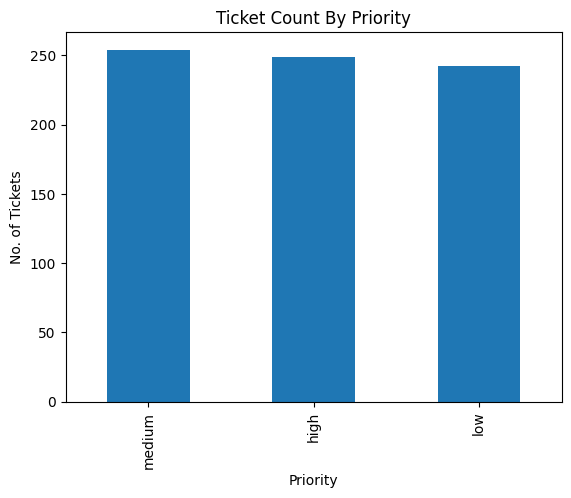

In [33]:
df['priority'].value_counts().plot(kind='bar')
plt.title('Ticket Count By Priority')
plt.xlabel('Priority')
plt.ylabel('No. of Tickets')
plt.show()

# **Bar chart of root cause categories**

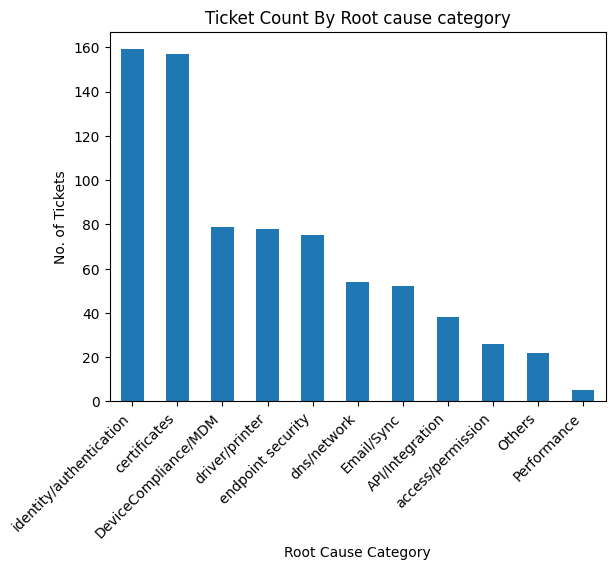

In [34]:
df['root_cause_category'].value_counts().plot(kind='bar')
plt.title('Ticket Count By Root cause category')
plt.xlabel('Root Cause Category')
plt.ylabel('No. of Tickets')
plt.xticks(rotation=45,ha='right')
plt.show()

"Identity/Authentication issues (159 tickets, ~21%) and Certificate-related problems (157 tickets, ~21%) together account for over 40% of all incidents — making them the two dominant categories, well ahead of Device Compliance/MDM, Driver/Printer, and Endpoint Security (each in the 75-80 ticket range). This suggests that improving self-service password/MFA recovery and certificate renewal monitoring would likely reduce ticket volume more than addressing any other single issue type."

# **Grouped bar chart of priority vs SLA category**

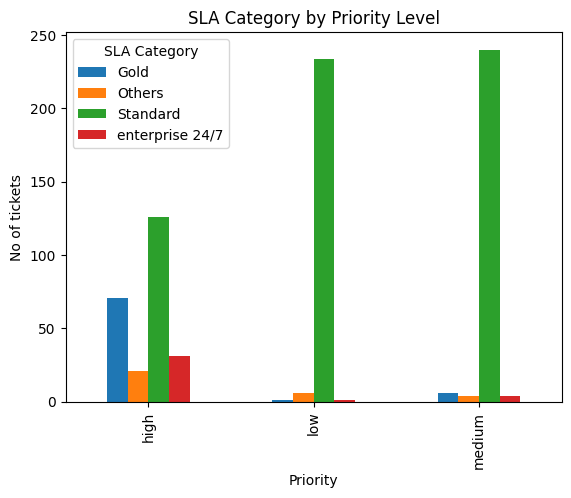

In [35]:
pd.crosstab(df['priority'],df['sla_category']).plot(kind='bar')
plt.title('SLA Category by Priority Level')
plt.xlabel('Priority')
plt.ylabel('No of tickets')
plt.legend(title='SLA Category')
plt.show()


"Gold-tier SLA tickets are overwhelmingly high-priority (71 out of 78 Gold tickets — about 91%), showing Gold is reserved almost exclusively for urgent issues. Standard SLA, by contrast, dominates medium and low priority tickets, while Enterprise/24x7 shows a similar pattern to Gold — concentrated in high-priority."